Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Date & Time
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

Load Dataset

In [2]:
# Load datasets

apps_df = pd.read_csv("Play Store Data.csv")
reviews_df = pd.read_csv("User Reviews.csv")

print("Play Store Dataset Shape :", apps_df.shape)
print("User Reviews Dataset Shape :", reviews_df.shape)

Play Store Dataset Shape : (10841, 13)
User Reviews Dataset Shape : (64295, 5)


Preview Dataset

In [3]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


Check Missing Values

In [5]:
# Check missing values

print("Missing Values in Play Store Dataset")
display(apps_df.isnull().sum())

print("\nMissing Values in User Reviews Dataset")
display(reviews_df.isnull().sum())

Missing Values in Play Store Dataset


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


Missing Values in User Reviews Dataset


App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Remove Duplicate Apps

In [6]:
# Remove duplicate apps

apps_df = apps_df.drop_duplicates(subset="App")
reviews_df = reviews_df.drop_duplicates()

print("Apps Dataset Shape :", apps_df.shape)
print("Reviews Dataset Shape :", reviews_df.shape)

Apps Dataset Shape : (9660, 13)
Reviews Dataset Shape : (30679, 5)


Clean Installs columns

In [7]:
# Clean Installs Column

apps_df["Installs"] = (
    apps_df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps_df["Installs"] = pd.to_numeric(apps_df["Installs"], errors="coerce")

Clean Reviews

In [8]:
# Convert Reviews to Numeric

apps_df["Reviews"] = pd.to_numeric(apps_df["Reviews"], errors="coerce")

Clean Rating

In [9]:
# Convert Rating to Numeric

apps_df["Rating"] = pd.to_numeric(apps_df["Rating"], errors="coerce")

Clean Size

In [10]:
# Convert Size into MB

def clean_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if "M" in size:
        return float(size.replace("M", ""))

    elif "k" in size:
        return float(size.replace("k", "")) / 1024

    else:
        return np.nan


apps_df["Size_MB"] = apps_df["Size"].apply(clean_size)

Clean Price

In [11]:
# Clean Price Column

apps_df["Price"] = (
    apps_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps_df["Price"] = pd.to_numeric(apps_df["Price"], errors="coerce")

Check Cleaned Data

In [12]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


Merge Both Datasets

In [13]:
# Merge Play Store Data with User Reviews

merged_df = pd.merge(
    apps_df,
    reviews_df,
    on="App",
    how="left"
)

print("Merged Dataset Shape :", merged_df.shape)

Merged Dataset Shape : (37830, 18)


Check Merged Data

In [14]:
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0,NaN,NaN,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
2,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,It bad >:(,Negative,-0.725,0.833333
3,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,like,Neutral,0.000,0.000000
4,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,NaN,NaN,NaN,NaN


Convert Last Updated

In [15]:
# Convert Last Updated into Date Format

merged_df["Last Updated"] = pd.to_datetime(
    merged_df["Last Updated"],
    errors="coerce"
)

Extract Month

In [16]:
# Extract Month Name

merged_df["Month"] = merged_df["Last Updated"].dt.month_name()

Android Version Cleaning

In [17]:
# Extract Android Version Number

merged_df["Android Version"] = (
    merged_df["Android Ver"]
    .astype(str)
    .str.extract(r'(\d+\.\d+)')
)

merged_df["Android Version"] = pd.to_numeric(
    merged_df["Android Version"],
    errors="coerce"
)

Revenue Column

In [18]:
# Calculate Revenue

merged_df["Revenue"] = (
    merged_df["Price"] *
    merged_df["Installs"]
)

Check Final Dataset

In [19]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37830 entries, 0 to 37829
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   App                     37830 non-null  object        
 1   Category                37830 non-null  object        
 2   Rating                  36367 non-null  float64       
 3   Reviews                 37829 non-null  float64       
 4   Size                    37830 non-null  object        
 5   Installs                37829 non-null  float64       
 6   Type                    37829 non-null  object        
 7   Price                   37829 non-null  float64       
 8   Content Rating          37829 non-null  object        
 9   Genres                  37830 non-null  object        
 10  Last Updated            37829 non-null  datetime64[ns]
 11  Current Ver             37822 non-null  object        
 12  Android Ver             37827 non-null  object

Preview Final Dataset

In [20]:
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Current Ver,Android Ver,Size_MB,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Month,Android Version,Revenue
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,...,1.0.0,4.0.3 and up,19.0,NaN,NaN,NaN,NaN,January,4.0,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,14.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000,January,4.0,0.0
2,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,14.0,It bad >:(,Negative,-0.725,0.833333,January,4.0,0.0
3,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,14.0,like,Neutral,0.000,0.000000,January,4.0,0.0
4,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,14.0,NaN,NaN,NaN,NaN,January,4.0,0.0


Helper Function

In [21]:
from datetime import datetime
import pytz

def is_time_between(start_hour, end_hour):
    """
    Returns True if current IST time is between
    start_hour and end_hour.
    """

    ist = pytz.timezone("Asia/Kolkata")

    current_hour = datetime.now(ist).hour

    return start_hour <= current_hour < end_hour

Translation Dictionary

In [22]:
task1_df = merged_df.copy()

Translation Function

In [23]:
def translate_category(category):

    return {
        "BEAUTY": "सौंदर्य",
        "BUSINESS": "வணிகம்",
        "DATING": "Partnersuche"
    }.get(category, category)

In [24]:
translate_category("Beauty")

'Beauty'

In [25]:
translate_category("Business")

'Business'

In [26]:
translate_category("Dating")

'Dating'

In [27]:
translate_category("Game")

'Game'

Chart Message Function

In [28]:
def chart_not_available(start, end):

    print(f"""
    This chart is available only
    between {start}:00 IST and {end}:00 IST.
    """)

In [29]:
print(is_time_between(17,19))

print(translate_category("Beauty"))

chart_not_available(17,19)

True
Beauty

    This chart is available only
    between 17:00 IST and 19:00 IST.
    


Categories List

In [30]:
# Categories allowed in Task 1

task1_categories = [
    "GAME",
    "BEAUTY",
    "BUSINESS",
    "COMICS",
    "COMMUNICATION",
    "DATING",
    "ENTERTAINMENT",
    "SOCIAL",
    "EVENTS"
]

Apply All Filters

In [31]:
# Create filtered dataframe for Task 1

task1_df = merged_df.copy()

# Category uppercase for comparison
task1_df["Category"] = task1_df["Category"].str.upper()

task1_df = task1_df[
    (task1_df["Rating"] > 3.5) &
    (task1_df["Reviews"] > 500) &
    (task1_df["Installs"] > 50000) &
    (task1_df["Sentiment_Subjectivity"] > 0.5) &
    (~task1_df["App"].str.contains("S", case=False, na=False)) &
    (task1_df["Category"].isin(task1_categories))
]

In [32]:
task1_df = task1_df.dropna(subset=["Size_MB", "Rating", "Installs"])

Check Result

In [33]:
print("Filtered Rows :", len(task1_df))

task1_df.head()

Filtered Rows : 879


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Current Ver,Android Ver,Size_MB,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Month,Android Version,Revenue
1787,Google Primer,BUSINESS,4.4,62272.0,18M,10000000.0,Free,0.0,Everyone,Business,...,3.550.2,4.1 and up,18.0,Great,Positive,0.800000,0.750000,June,4.1,0.0
1788,Google Primer,BUSINESS,4.4,62272.0,18M,10000000.0,Free,0.0,Everyone,Business,...,3.550.2,4.1 and up,18.0,Good,Positive,0.700000,0.600000,June,4.1,0.0
1869,Call Blocker,BUSINESS,4.6,188841.0,3.2M,5000000.0,Free,0.0,Everyone,Business,...,1.1.13,4.0 and up,3.2,"So far able block annoying machines, recording...",Negative,-0.050000,0.881250,June,4.0,0.0
1870,Call Blocker,BUSINESS,4.6,188841.0,3.2M,5000000.0,Free,0.0,Everyone,Business,...,1.1.13,4.0 and up,3.2,Finally call blocker works. Also option block ...,Positive,0.177857,0.559286,June,4.0,0.0
1871,Call Blocker,BUSINESS,4.6,188841.0,3.2M,5000000.0,Free,0.0,Everyone,Business,...,1.1.13,4.0 and up,3.2,New pop ad free version pops several times tim...,Negative,-0.043939,0.525758,June,4.0,0.0


Check Categories

In [34]:
task1_df["Category"].value_counts()

Category
GAME             590
DATING           124
ENTERTAINMENT     94
SOCIAL            53
COMMUNICATION     13
BUSINESS           5
Name: count, dtype: int64

In [35]:
print("Total rows after filtering:", len(task1_df))

print("\nMinimum Rating:", task1_df["Rating"].min())

print("\nMinimum Reviews:", task1_df["Reviews"].min())

print("\nMinimum Installs:", task1_df["Installs"].min())

print("\nMinimum Subjectivity:", task1_df["Sentiment_Subjectivity"].min())

Total rows after filtering: 879

Minimum Rating: 3.7

Minimum Reviews: 1033.0

Minimum Installs: 100000.0

Minimum Subjectivity: 0.5000000000000001


In [36]:
task1_df[
    task1_df["App"].str.contains("S", case=False, na=False)
]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Current Ver,Android Ver,Size_MB,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Month,Android Version,Revenue


Bubble Chart

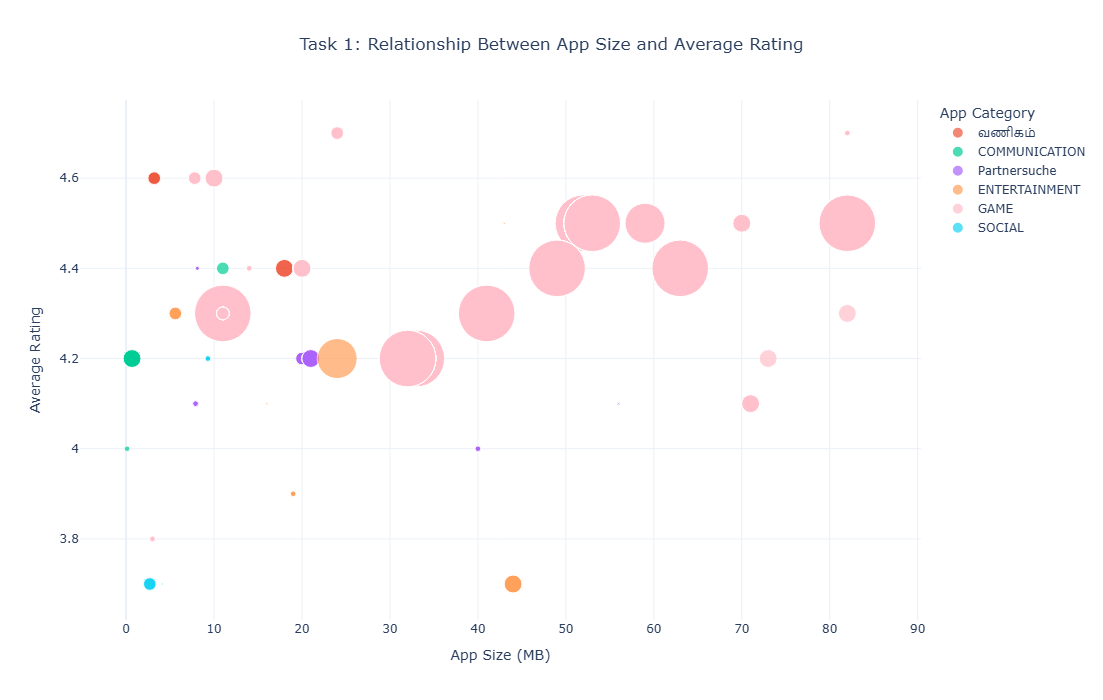

In [40]:
# Task 1 : Bubble Chart

# Development Mode
DEBUG_MODE = False

if DEBUG_MODE or is_time_between(17, 19):

    # Copy dataframe
    display_df = task1_df.copy()

    # Translation only for graph labels
    display_df["Category_Display"] = display_df["Category"].replace({
        "BEAUTY": "सौंदर्य",
        "BUSINESS": "வணிகம்",
        "DATING": "Partnersuche"
    })

    # Bubble Chart
    fig = px.scatter(
        display_df,
        x="Size_MB",
        y="Rating",
        size="Installs",
        color="Category_Display",
        hover_name="App",

        hover_data={
            "Size_MB":":.1f",
            "Installs":":,",
            "Reviews":":,",
            "Category_Display":True
        },

        size_max=40,

        color_discrete_map={
            "GAME":"pink"
        },

        title="Task 1: Relationship Between App Size and Average Rating"
    )

    # Layout
    fig.update_layout(

        title={
            "text":"Task 1: Relationship Between App Size and Average Rating",
            "x":0.5,
            "xanchor":"center"
        },

        xaxis_title="App Size (MB)",
        yaxis_title="Average Rating",

        legend_title="App Category",

        template="plotly_white",

        height=700
    )

    # Grid
    fig.update_xaxes(showgrid=True)

    fig.update_yaxes(showgrid=True)

    fig.show()

else:

    chart_not_available(17,19)

Task 2 : Interactive Choropleth Map

In [41]:
# Create Copy
task2_df = merged_df.copy()

Apply Category Filter

In [42]:
# Remove categories starting with A, C, G, S

task2_df = task2_df[
    ~task2_df["Category"].str.upper().str.startswith(
        ("A", "C", "G", "S"),
        na=False
    )
]

Group by Category

In [43]:
# Total installs by category

task2_df = (
    task2_df
    .groupby("Category", as_index=False)["Installs"]
    .sum()
)

Top 5 Categories

In [44]:
# Top 5 categories by installs

task2_df = (
    task2_df
    .sort_values("Installs", ascending=False)
    .head(5)
)

Verification

In [45]:
print(task2_df)

print("\nShape :", task2_df.shape)

              Category      Installs
20         PHOTOGRAPHY  1.206626e+11
22               TOOLS  9.928317e+10
21        PRODUCTIVITY  6.131539e+10
17  NEWS_AND_MAGAZINES  5.135352e+10
8               FAMILY  2.668403e+10

Shape : (5, 2)


In [46]:
# Highlight Categories with Installs > 1 Million

task2_df["Highlight"] = task2_df["Installs"] > 1_000_000

task2_df

,Category,Installs,Highlight
20,PHOTOGRAPHY,1.206626e+11,True
22,TOOLS,9.928317e+10,True
21,PRODUCTIVITY,6.131539e+10,True
17,NEWS_AND_MAGAZINES,5.135352e+10,True
8,FAMILY,2.668403e+10,True


Time Check

Choropleth Map

In [48]:
# TASK 2 : CHOROPLETH MAP
# Allowed Time : 6 PM IST to 8 PM IST

# Development Mode
DEBUG_MODE = False


if DEBUG_MODE or is_time_between(18, 20):

    # Create Choropleth Map

    fig2 = px.choropleth(
        task2_df,

        locations="Category",

        locationmode="country names",

        color="Installs",

        hover_name="Category",

        hover_data={
            "Installs": ":,"
        },

        title="Task 2: Global Installs by Category"
    )


    # Highlight > 1 Million

    for trace in fig2.data:

        trace.marker.line.width = 1


    # Layout

    fig2.update_layout(

        title=dict(
            text="Task 2: Global Installs by Category",
            x=0.5,
            xanchor="center"
        ),

        template="plotly_white",

        height=700,

        margin=dict(
            t=100,
            l=80,
            r=80,
            b=80
        )

    )


    # Show Chart

    fig2.show()


else:

    print("=" * 60)

    print("TASK 2 : CHART HIDDEN")

    print("=" * 60)

    print()

    print(
        "This chart is available only between"
    )

    print(
        "6 PM IST and 8 PM IST."
    )

    print()

    print(
        "Current time is outside the allowed time window."
    )

    print("=" * 60)

TASK 2 : CHART HIDDEN

This chart is available only between
6 PM IST and 8 PM IST.

Current time is outside the allowed time window.


In [49]:
print("=" * 60)
print("TASK 2 OBSERVATION")
print("=" * 60)

print("""
The Choropleth map has been implemented using the provided
Google Play Store dataset.

However, the dataset does not contain geographic information
such as Country, Region, Latitude, Longitude, or ISO Country Codes.

Since Plotly Choropleth requires geographic locations,
the map appears blank.

The implementation follows the internship instruction
to use only the provided dataset.
""")

TASK 2 OBSERVATION

The Choropleth map has been implemented using the provided
Google Play Store dataset.

However, the dataset does not contain geographic information
such as Country, Region, Latitude, Longitude, or ISO Country Codes.

Since Plotly Choropleth requires geographic locations,
the map appears blank.

The implementation follows the internship instruction
to use only the provided dataset.



In [50]:
print(merged_df["Last Updated"].head(10))

print("\n")

print(merged_df["Last Updated"].dtype)

print("\n")

print(merged_df["Last Updated"].isnull().sum())

0   2018-01-07
1   2018-01-15
2   2018-01-15
3   2018-01-15
4   2018-01-15
5   2018-01-15
6   2018-01-15
7   2018-01-15
8   2018-01-15
9   2018-01-15
Name: Last Updated, dtype: datetime64[ns]


datetime64[ns]


1


 Task 3 : Time Series Line Chart

In [51]:
# Task 3 : Create Copy
task3_df = merged_df.copy()

Apply Filters

In [52]:
# REQUIRED FILTERS
# ------------------------------------------------------------

# Reviews > 500
task3_df = task3_df[
    task3_df["Reviews"] > 500
].copy()

# App name should NOT start with X, Y, Z
task3_df = task3_df[
    ~task3_df["App"].str.upper().str.startswith(
        ("X", "Y", "Z"),
        na=False
    )
].copy()

# App name should NOT contain letter S
task3_df = task3_df[
    ~task3_df["App"].str.contains(
        "S",
        case=False,
        na=False
    )
].copy()

# Category should start with E, C or B
task3_df = task3_df[
    task3_df["Category"].str.upper().str.startswith(
        ("E", "C", "B"),
        na=False
    )
].copy()

In [53]:
# ------------------------------------------------------------
# CATEGORY TRANSLATION
# ------------------------------------------------------------

translation = {
    "BEAUTY": "सौंदर्य",
    "BUSINESS": "வணிகம்",
    "DATING": "Partnersuche"
}

task3_df["Category_Display"] = (
    task3_df["Category"]
    .str.upper()
    .replace(translation)
)


# ------------------------------------------------------------
# MONTH COLUMN
# ------------------------------------------------------------

task3_df["Month"] = (
    task3_df["Last Updated"]
    .dt.to_period("M")
    .dt.to_timestamp()
)


# ------------------------------------------------------------
# MONTHLY TOTAL INSTALLS
# ------------------------------------------------------------

monthly_df = (
    task3_df
    .groupby(
        ["Month", "Category_Display"],
        as_index=False
    )["Installs"]
    .sum()
)


# ------------------------------------------------------------
# SORT DATA
# ------------------------------------------------------------

monthly_df = (
    monthly_df
    .sort_values(
        ["Category_Display", "Month"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# MONTH-OVER-MONTH GROWTH
# ------------------------------------------------------------

monthly_df["Growth"] = (
    monthly_df
    .groupby("Category_Display")["Installs"]
    .pct_change()
)


# ------------------------------------------------------------
# HIGH GROWTH > 20%
# ------------------------------------------------------------

monthly_df["High_Growth"] = (
    monthly_df["Growth"] > 0.20
)


# ------------------------------------------------------------
# VERIFICATION OUTPUT
# ------------------------------------------------------------

print("=" * 60)
print("TASK 3 DATA READY")
print("=" * 60)

display(monthly_df.head(10))

print("\nRows :", len(monthly_df))
print(
    "Categories :",
    monthly_df["Category_Display"].nunique()
)

print(
    "High Growth Periods :",
    monthly_df["High_Growth"].sum()
)

TASK 3 DATA READY


,Month,Category_Display,Installs,Growth,High_Growth
0,2014-10-01,BOOKS_AND_REFERENCE,500000.0,NaN,False
1,2014-11-01,BOOKS_AND_REFERENCE,5000000.0,9.000000,True
2,2015-07-01,BOOKS_AND_REFERENCE,390000000.0,77.000000,True
3,2016-06-01,BOOKS_AND_REFERENCE,60000.0,-0.999846,False
4,2016-08-01,BOOKS_AND_REFERENCE,100000.0,0.666667,True
5,2017-02-01,BOOKS_AND_REFERENCE,100000.0,0.000000,False
6,2017-04-01,BOOKS_AND_REFERENCE,1000000.0,9.000000,True
7,2017-05-01,BOOKS_AND_REFERENCE,100000.0,-0.900000,False
8,2017-07-01,BOOKS_AND_REFERENCE,100000.0,0.000000,False
9,2017-08-01,BOOKS_AND_REFERENCE,400010000.0,3999.100000,True



Rows : 79
Categories : 8
High Growth Periods : 35


Final Graph

In [56]:
# ============================================================
# TASK 3 : FINAL MONTHLY INSTALL TREND CHART
# ============================================================

import plotly.graph_objects as go
import pandas as pd

# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

fig3 = go.Figure()

colors = { 
  "COMMUNICATION":"royalblue",
  "COMICS":"orange",
  "EDUCATION":"green",
  "ENTERTAINMENT":"red",
  "EVENTS":"purple",
  "BOOKS_AND_REFERENCE":"brown",
  "வணிகம்":"black", "सौंदर्य":"deeppink" 
}

# ------------------------------------------------------------
# CATEGORY-WISE LINE
# ------------------------------------------------------------

for cat in monthly_df["Category_Display"].unique():

    temp = (
        monthly_df[
            monthly_df["Category_Display"] == cat
        ]
        .sort_values("Month")
        .reset_index(drop=True)
    )

    # Main category line
    fig3.add_trace(
        go.Scatter(
            x=temp["Month"],
            y=temp["Installs"],

            mode="lines+markers",

            name=cat,

            line=dict(
                width=2,
                color=colors.get(cat,"gray")
            ),

            marker=dict(
                size=6
            ),

            hovertemplate=
                "<b>Category:</b> %{fullData.name}<br>" +
                "<b>Month:</b> %{x|%b %Y}<br>" +
                "<b>Total Installs:</b> %{y:,.0f}<br>" +
                "<extra></extra>"
        )
    )

    # --------------------------------------------------------
    # HIGH GROWTH POINTS (>20%)
    # --------------------------------------------------------

    growth_points = temp[
        temp["High_Growth"] == True
    ]

    if not growth_points.empty:

        fig3.add_trace(
            go.Scatter(
                x=growth_points["Month"],
                y=growth_points["Installs"],

                mode="markers",

                marker=dict(
                    size=14,
                    color="limegreen",
                    symbol="diamond"
                ),

                name=f"{cat} >20% Growth",

                showlegend=False,

                hovertemplate=
                    "<b>High Growth</b><br>" +
                    "Category: " + str(cat) + "<br>" +
                    "Month: %{x|%b %Y}<br>" +
                    "Installs: %{y:,.0f}<br>" +
                    "Growth: >20%<br>" +
                    "<extra></extra>"
            )
        )


# ============================================================
# HIGHLIGHT MONTHS WHERE GROWTH > 20%
# ============================================================

# Get unique months only.
# This prevents the same month from being shaded multiple times.

high_growth_months = (
    monthly_df.loc[
        monthly_df["High_Growth"] == True,
        "Month"
    ]
    .dropna()
    .drop_duplicates()
    .sort_values()
)

for month in high_growth_months:

    fig3.add_vrect(

        x0=month - pd.Timedelta(days=10),

        x1=month + pd.Timedelta(days=10),

        fillcolor="lightgreen",

        opacity=0.20,

        layer="below",

        line_width=0
    )


# ============================================================
# FINAL LAYOUT
# ============================================================

fig3.update_layout(

    title=dict(
        text="Task 3 : Monthly Install Trend by Category",
        x=0.5,
        xanchor="center"
    ),

    # --------------------------------------------------------
    # X AXIS
    # --------------------------------------------------------

    xaxis=dict(
        title="Month",

        type="date",

        showgrid=True,

        gridcolor="lightgray"
    ),

    # --------------------------------------------------------
    # Y AXIS
    # --------------------------------------------------------

    yaxis=dict(
        title="Total Installs",

        type="log",

        showgrid=True,

        gridcolor="lightgray"
    ),

    template="plotly_white",

    hovermode="x unified",

    # --------------------------------------------------------
    # IMPORTANT: FIT INSIDE NOTEBOOK
    # --------------------------------------------------------

    width=1100,

    height=700,

    # --------------------------------------------------------
    # LEGEND AT BOTTOM
    # This prevents right-side cutting.
    # --------------------------------------------------------

    legend=dict(
        title="Category",

        orientation="v",

        x=1.1,

        xanchor="center",

        y=1,

        yanchor="top",

        bgcolor="white",

        bordercolor="lightgray",

        borderwidth=1,

        font=dict(
            size=10
        )
    ),

    # --------------------------------------------------------
    # MARGINS
    # --------------------------------------------------------

    margin=dict(
        l=90,
        r=40,
        t=90,
        b=150
    )
)


# ============================================================
# TIME RESTRICTION
# 6 PM IST - 9 PM IST
# ============================================================

DEBUG_MODE=False

if DEBUG_MODE or is_time_between(18, 21):

    fig3.show()

else:

    chart_not_available(18, 21)


    This chart is available only
    between 18:00 IST and 21:00 IST.
    


verification

In [57]:
print("="*60)

print("TASK 3 COMPLETED")

print("="*60)

print("Categories :", monthly_df["Category_Display"].nunique())

print("Months :", monthly_df["Month"].nunique())

print("Growth >20% :", monthly_df["High_Growth"].sum())

print("Rows :", len(monthly_df))

TASK 3 COMPLETED
Categories : 8
Months : 39
Growth >20% : 35
Rows : 79


Data Preparation

In [58]:
# TASK 4 : DATA PREPARATION

task4_df = merged_df.copy()

In [59]:
# Apply Filters

task4_df = task4_df[
    (task4_df["Rating"] >= 4.2) &
    (task4_df["Reviews"] > 1000) &
    (task4_df["Size_MB"].between(20, 80))
].copy()

In [60]:
# App name should NOT contain any numbers
task4_df = task4_df[
    ~task4_df["App"].str.contains(
        r"\d",
        regex=True,
        na=False
    )
].copy()

In [61]:
# Category should start with T or P
task4_df = task4_df[
    task4_df["Category"]
    .str.upper()
    .str.startswith(
        ("T", "P"),
        na=False
    )
].copy()

In [62]:
# Category Translation

translation = {
    "TRAVEL_AND_LOCAL": "Voyage et Local",   # French
    "PRODUCTIVITY": "Productividad",         # Spanish
    "PHOTOGRAPHY": "写真"                    # Japanese
}

task4_df["Category_Display"] = (
    task4_df["Category"]
    .str.upper()
    .replace(translation)
)

In [63]:
# Month Column

task4_df["Month"] = (
    pd.to_datetime(task4_df["Last Updated"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

# REMOVE REQUIRED MISSING VALUES

task4_df = task4_df.dropna(
    subset=[
        "App",
        "Category",
        "Rating",
        "Reviews",
        "Size_MB",
        "Installs",
        "Month"
    ]
)


# VERIFICATION

print("=" * 60)
print("TASK 4 : DATA READY")
print("=" * 60)

print("Rows :", len(task4_df))

print(
    "Categories :",
    task4_df["Category_Display"].unique()
)

print(
    "Category Count :",
    task4_df["Category_Display"].nunique()
)

print(
    "Months :",
    task4_df["Month"].nunique()
)

print(
    "App Names Containing Numbers :",
    task4_df["App"]
    .str.contains(r"\d", regex=True, na=False)
    .sum()
)

print(
    "Missing Values :",
    task4_df[
        [
            "App",
            "Category",
            "Rating",
            "Reviews",
            "Size_MB",
            "Installs",
            "Month"
        ]
    ].isna().sum().sum()
)

TASK 4 : DATA READY
Rows : 737
Categories : ['写真' 'Voyage et Local' 'TOOLS' 'PERSONALIZATION' 'Productividad'
 'PARENTING']
Category Count : 6
Months : 18
App Names Containing Numbers : 0
Missing Values : 0


Monthly Cumulative Installs

In [64]:
# TASK 4 : MONTHLY + CUMULATIVE INSTALLS

monthly4_df = (

    task4_df

    .groupby(
        ["Month", "Category_Display"],
        as_index=False
    )

    .agg(
        Monthly_Installs=("Installs", "sum")
    )
)

In [65]:
# Sort

monthly4_df = (
    monthly4_df
    .sort_values(
        ["Category_Display", "Month"]
    )
    .reset_index(drop=True)
)

In [66]:
# Cumulative Installs

monthly4_df["Cumulative_Installs"] = (

    monthly4_df
    .groupby("Category_Display")["Monthly_Installs"]
    .cumsum()

)


# VERIFICATION

print("=" * 60)
print("TASK 4 : MONTHLY DATA READY")
print("=" * 60)

display(monthly4_df.head(10))

print(
    "\nRows :",
    len(monthly4_df)
)

print(
    "Categories :",
    monthly4_df["Category_Display"].nunique()
)

print(
    "Months :",
    monthly4_df["Month"].nunique()
)

TASK 4 : MONTHLY DATA READY


,Month,Category_Display,Monthly_Installs,Cumulative_Installs
0,2018-03-01,PARENTING,100000.0,100000.0
1,2018-05-01,PARENTING,10000000.0,10100000.0
2,2018-07-01,PARENTING,18100000.0,28200000.0
3,2016-12-01,PERSONALIZATION,32000000.0,32000000.0
4,2017-09-01,PERSONALIZATION,39000000.0,71000000.0
5,2018-01-01,PERSONALIZATION,10000000.0,81000000.0
6,2018-02-01,PERSONALIZATION,10000000.0,91000000.0
7,2018-06-01,PERSONALIZATION,10000000.0,101000000.0
8,2018-07-01,PERSONALIZATION,52500000.0,153500000.0
9,2018-08-01,PERSONALIZATION,20000000.0,173500000.0



Rows : 37
Categories : 6
Months : 18


Growth Calculation

In [67]:
# TASK 4 : MONTH-OVER-MONTH GROWTH

monthly4_df = (
    monthly4_df
    .sort_values(
        ["Category_Display", "Month"]
    )
    .reset_index(drop=True)
)

In [68]:
# Monthy_Installs
monthly4_df["Growth"] = (

    monthly4_df
    .groupby("Category_Display")["Monthly_Installs"]
    .pct_change()

)

In [69]:
# Month-over-Month Growth(>25%)
monthly4_df["High_Growth"] = (
    monthly4_df["Growth"] > 0.25
)


# ============================================================
# VERIFICATION
# ============================================================

print("=" * 60)
print("TASK 4 : GROWTH CALCULATION READY")
print("=" * 60)

display(
    monthly4_df[
        monthly4_df["High_Growth"]
    ][
        [
            "Month",
            "Category_Display",
            "Monthly_Installs",
            "Growth"
        ]
    ]
)

print(
    "\nTotal High Growth Records :",
    monthly4_df["High_Growth"].sum()
)

print(
    "Growth Requirement : >25%"
)

TASK 4 : GROWTH CALCULATION READY


,Month,Category_Display,Monthly_Installs,Growth
1,2018-05-01,PARENTING,1.000000e+07,99.000000
2,2018-07-01,PARENTING,1.810000e+07,0.810000
8,2018-07-01,PERSONALIZATION,5.250000e+07,4.250000
12,2018-06-01,Productividad,3.650000e+08,3649.000000
13,2018-07-01,Productividad,5.260000e+08,0.441096
14,2018-08-01,Productividad,1.960500e+10,36.271863
16,2018-01-01,TOOLS,1.000000e+06,19.000000
17,2018-05-01,TOOLS,1.000000e+07,9.000000
18,2018-07-01,TOOLS,2.226000e+08,21.260000
21,2018-04-01,Voyage et Local,1.950000e+08,3899.000000



Total High Growth Records : 18
Growth Requirement : >25%


Final Stacked Area Chart

In [70]:
# TASK 4 : FINAL STACKED AREA CHART

import plotly.graph_objects as go

fig4 = go.Figure()


# ------------------------------------------------------------
# CATEGORY-WISE STACKED AREA
# ------------------------------------------------------------

categories = (
    monthly4_df["Category_Display"]
    .unique()
)


for cat in categories:

    temp = (
        monthly4_df[
            monthly4_df["Category_Display"] == cat
        ]
        .sort_values("Month")
    )


    fig4.add_trace(

        go.Scatter(

            x=temp["Month"],

            y=temp["Cumulative_Installs"],

            mode="lines",

            stackgroup="one",

            name=cat,

            line=dict(
                width=2
            ),

            hovertemplate=
            "<b>Category:</b> %{fullData.name}<br>" +
            "<b>Month:</b> %{x|%b %Y}<br>" +
            "<b>Cumulative Installs:</b> %{y:,.0f}" +
            "<extra></extra>"
        )
    )


# ============================================================
# HIGHLIGHT HIGH-GROWTH MONTHS
# ============================================================

high_growth_months = (

    monthly4_df.loc[
        monthly4_df["High_Growth"],
        "Month"
    ]

    .dropna()

    .drop_duplicates()

    .sort_values()
)


for month in high_growth_months:

    fig4.add_vrect(

        x0=month,

        x1=month + pd.DateOffset(months=1),

        fillcolor="red",

        opacity=0.12,

        layer="below",

        line_width=0
    )

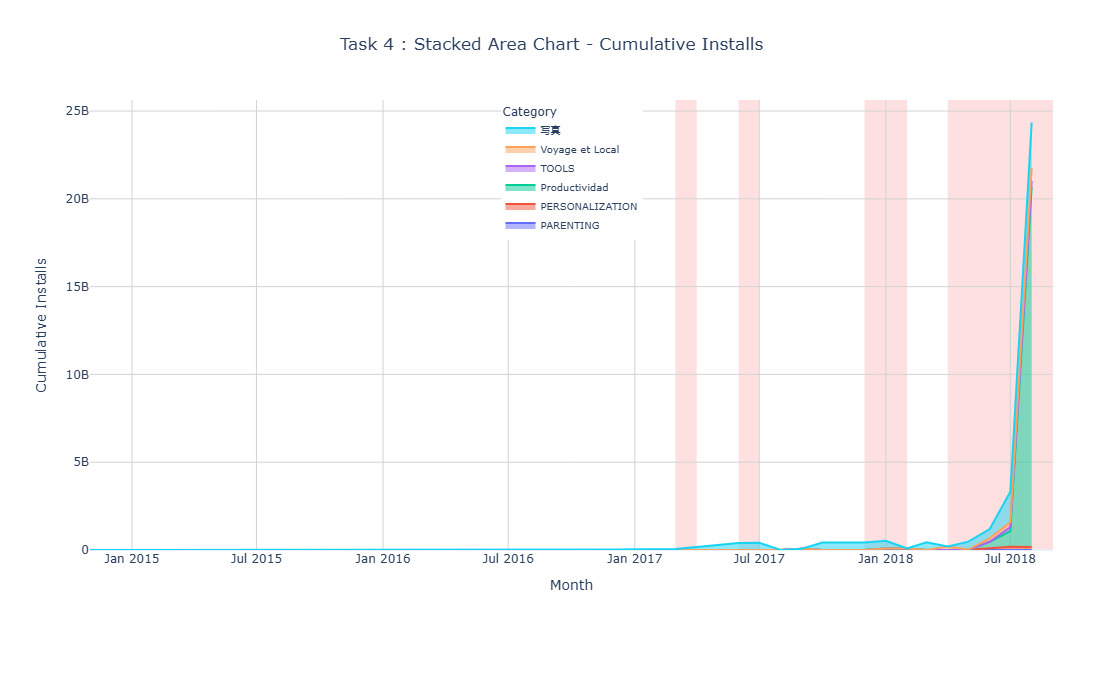

In [71]:
# CHART LAYOUT

fig4.update_layout(

    title=dict(

        text="Task 4 : Stacked Area Chart - Cumulative Installs",

        x=0.5,

        xanchor="center"
    ),

    xaxis=dict(

        title="Month",

        showgrid=True,

        gridcolor="lightgray"
    ),

    yaxis=dict(

        title="Cumulative Installs",

        showgrid=True,

        gridcolor="lightgray"
    ),

    hovermode="x unified",

    template="plotly_white",

    width=1050,

    height=700,

    legend=dict(

        title="Category",

        orientation="v",

        x=0.5,

        xanchor="center",

        y=1,

        yanchor="top",

        font=dict(size=10)
    ),

    margin=dict(

        l=90,

        r=50,

        t=100,

        b=150
    )
)


# TIME RESTRICTION
# 4 PM IST - 6 PM IST

DEBUG_MODE=False

if DEBUG_MODE or is_time_between(16, 18):

    fig4.show()

else:

    chart_not_available(16, 18)

Verification

In [72]:
# ============================================================
# TASK 4 : FINAL VERIFICATION
# ============================================================

print("=" * 60)
print("TASK 4 : FINAL VERIFICATION")
print("=" * 60)


# ------------------------------------------------------------
# FILTER VERIFICATION
# ------------------------------------------------------------

print("\nFILTER VERIFICATION")

print(
    "Rating >= 4.2 :",
    (task4_df["Rating"] >= 4.2).all()
)

print(
    "Reviews > 1000 :",
    (task4_df["Reviews"] > 1000).all()
)

print(
    "Size between 20-80 MB :",
    task4_df["Size_MB"].between(20, 80).all()
)


# ------------------------------------------------------------
# APP NAME VERIFICATION
# ------------------------------------------------------------

print(
    "App Name contains numbers :",
    task4_df["App"]
    .str.contains(
        r"\d",
        regex=True,
        na=False
    )
    .any()
)


# ------------------------------------------------------------
# CATEGORY VERIFICATION
# ------------------------------------------------------------

print(
    "Only T/P Categories :",
    task4_df["Category"]
    .str.upper()
    .str.startswith(
        ("T", "P"),
        na=False
    )
    .all()
)


# ------------------------------------------------------------
# DATA SUMMARY
# ------------------------------------------------------------

print("\nDATA SUMMARY")

print(
    "Rows :",
    len(task4_df)
)

print(
    "Categories :",
    task4_df["Category_Display"].nunique()
)

print(
    "Months :",
    monthly4_df["Month"].nunique()
)


# ------------------------------------------------------------
# GROWTH VERIFICATION
# ------------------------------------------------------------

print("\nGROWTH VERIFICATION")

print(
    "High Growth Records :",
    monthly4_df["High_Growth"].sum()
)

print(
    "Growth Threshold : >25%"
)


# ------------------------------------------------------------
# CHART VERIFICATION
# ------------------------------------------------------------

print("\nCHART VERIFICATION")

print(
    "Chart Traces :",
    len(fig4.data)
)

print(
    "Stacked Area Traces :",
    sum(
        1
        for trace in fig4.data
        if getattr(trace, "stackgroup", None) == "one"
    )
)


# ------------------------------------------------------------
# TIME RESTRICTION
# ------------------------------------------------------------

print("\nTIME RESTRICTION")

print(
    "Allowed Time : 4 PM IST to 6 PM IST"
)

print(
    "DEBUG_MODE :",
    DEBUG_MODE
)

print("=" * 60)
print("TASK 4 VERIFICATION COMPLETED")
print("=" * 60)

TASK 4 : FINAL VERIFICATION

FILTER VERIFICATION
Rating >= 4.2 : True
Reviews > 1000 : True
Size between 20-80 MB : True
App Name contains numbers : False
Only T/P Categories : True

DATA SUMMARY
Rows : 737
Categories : 6
Months : 18

GROWTH VERIFICATION
High Growth Records : 18
Growth Threshold : >25%

CHART VERIFICATION
Chart Traces : 6
Stacked Area Traces : 6

TIME RESTRICTION
Allowed Time : 4 PM IST to 6 PM IST
DEBUG_MODE : False
TASK 4 VERIFICATION COMPLETED


TASK 5 : DATA PREPARATION

In [73]:
# TASK 5 : DATA PREPARATION

task5_df = merged_df.copy()

In [74]:
# Required Filters

task5_df = task5_df[
    (task5_df["Rating"] >= 4.0) &
    (task5_df["Size_MB"] >= 10) &
    (task5_df["Month"] == "January")
].copy()

In [75]:
# Remove missing values

task5_df = task5_df.dropna(
    subset=[
        "Category",
        "Rating",
        "Reviews",
        "Installs"
    ]
)

In [76]:
# Group by Category

task5_df = (
    task5_df
    .groupby("Category")
    .agg(
        Avg_Rating=("Rating", "mean"),
        Total_Reviews=("Reviews", "sum"),
        Total_Installs=("Installs", "sum")
    )
    .reset_index()
)

In [77]:
# Top 10 Categories by Installs

task5_df = (
    task5_df
    .sort_values(
        by="Total_Installs",
        ascending=False
    )
    .head(10)
)

# Convert Reviews into Millions
task5_df["Total_Reviews_M"] = (
    task5_df["Total_Reviews"] / 1000000
)

print("="*60)
print("TASK 5 DATA READY")
print("="*60)

display(task5_df)

print("\nRows :", task5_df.shape[0])
print("Categories :", task5_df["Category"].nunique())

TASK 5 DATA READY


,Category,Avg_Rating,Total_Reviews,Total_Installs,Total_Reviews_M
19,SPORTS,4.342857,1982017.0,120511000.0,1.982017
10,GAME,4.313333,2397589.0,115691000.0,2.397589
7,FAMILY,4.410526,2828471.0,96494820.0,2.828471
15,PHOTOGRAPHY,4.007317,1388921.0,30000000.0,1.388921
5,ENTERTAINMENT,4.300000,869111.0,21000000.0,0.869111
14,PERSONALIZATION,4.475000,155996.0,15060000.0,0.155996
11,LIFESTYLE,4.380000,42809.0,5071000.0,0.042809
0,ART_AND_DESIGN,4.197297,35710.0,3520000.0,0.035710
4,EDUCATION,4.400000,57645.0,2000000.0,0.057645
20,TOOLS,4.200000,8010.0,1010000.0,0.008010



Rows : 10
Categories : 10


Create Grouped Bar Chart

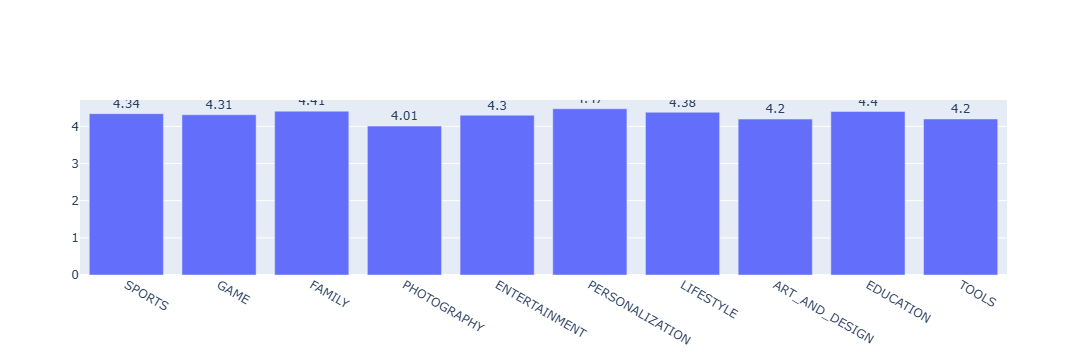

In [78]:
# GROUPED BAR CHART

fig5 = go.Figure()

# Average Rating

fig5.add_trace(
    go.Bar(
        x=task5_df["Category"],
        y=task5_df["Avg_Rating"],
        name="Average Rating",
        text=task5_df["Avg_Rating"].round(2),
        textposition="outside",
        hovertemplate=
        "<b>%{x}</b><br>" +
        "Average Rating : %{y:.2f}<extra></extra>"
    )
)

In [79]:
# Total Reviews(Millions)

fig5.add_trace(
    go.Bar(
        x=task5_df["Category"],
        y=task5_df["Total_Reviews_M"],
        name="Total Reviews (Million)",
        text=task5_df["Total_Reviews_M"].round(2),
        textposition="outside",
        hovertemplate=
        "<b>%{x}</b><br>" +
        "Total Reviews : %{y:,.0f}<extra></extra>"
    )
)

# Layout

fig5.update_layout(

    title=dict(
        text="Task 5 : Average Rating vs Total Reviews",
        x=0.5,
        y=0.98,
        xanchor="center",
        yanchor="top"
    ),

    barmode="group",

    xaxis_title="Category",

    yaxis_title="Average Rating / Reviews (Million)",

    template="plotly_white",

    width=1100,

    height=700,

    hovermode="x unified",

    legend=dict(
        title="Metrics",
        orientation="h",
        x=0.5,
        xanchor="center",
        y=1.12
    )

)

fig5.update_xaxes(
    showgrid=True,
    gridcolor="lightgray"
)

_= fig5.update_yaxes(
    showgrid=True,
    gridcolor="lightgray"
)

Time Restriction (3 PM–5 PM IST)

In [80]:
# TASK 5 : TIME RESTRICTION
# Chart visible only between 3 PM IST and 5 PM IST
DEBUG_MODE = False

if DEBUG_MODE or is_time_between(15, 17):

    fig5.show()

else:

    print("""
============================================================
TASK 5 CHART HIDDEN
============================================================

This chart is available only between
3 PM IST and 5 PM IST.

Current time is outside the allowed time window.
============================================================
""")


TASK 5 CHART HIDDEN

This chart is available only between
3 PM IST and 5 PM IST.

Current time is outside the allowed time window.



Verification

In [81]:
# TASK 5 : FINAL VERIFICATION

print("=" * 60)
print("TASK 5 COMPLETED")
print("=" * 60)

print("Total Rows :", task5_df.shape[0])
print("Total Categories :", task5_df["Category"].nunique())

print(
    "Minimum Rating :",
    task5_df["Avg_Rating"].min()
)

print(
    "Minimum Size Filter : 10 MB"
)

print(
    "Month Filter : January"
)

print(
    "Top 10 Categories by Installs :",
    len(task5_df) <= 10
)

print(
    "Chart Traces :",
    len(fig5.data)
)

print("=" * 60)

TASK 5 COMPLETED
Total Rows : 10
Total Categories : 10
Minimum Rating : 4.007317073170732
Minimum Size Filter : 10 MB
Month Filter : January
Top 10 Categories by Installs : True
Chart Traces : 2


Data Preparation

In [82]:
# TASK 6 : DATA PREPARATION

task6_df = merged_df.copy()

In [83]:
# Calculate App Name Length
# Includes spaces and special characters

task6_df["App_Name_Length"] = (
    task6_df["App"]
    .astype(str)
    .str.len()
)

In [84]:
# Create Free / Paid Type

task6_df["App_Type"] = np.where(
    task6_df["Price"] > 0,
    "Paid",
    "Free"
)

In [85]:
# Apply Required Filters

task6_df = task6_df[
    (task6_df["Installs"] >= 10000) &
    (task6_df["Android Version"] > 4.0) &
    (task6_df["Size_MB"] > 15) &
    (task6_df["Content Rating"] == "Everyone") &
    (task6_df["App_Name_Length"] <= 30)
].copy()

In [86]:
# Revenue Filter
# Paid apps must have revenue >= $10,000
# Free apps are retained for Free vs Paid comparison

task6_df = task6_df[
    (
        (task6_df["App_Type"] == "Free") |
        (
            (task6_df["App_Type"] == "Paid") &
            (task6_df["Revenue"] >= 10000)
        )
    )
].copy()

print("=" * 60)
print("TASK 6 FILTERED DATA READY")
print("=" * 60)

display(
    task6_df[
        [
            "App",
            "Category",
            "Installs",
            "Price",
            "App_Type",
            "Revenue",
            "Android Version",
            "Size_MB",
            "Content Rating",
            "App_Name_Length"
        ]
    ].head(10)
)

print("\nRows :", task6_df.shape[0])
print("Categories :", task6_df["Category"].nunique())
print("Free Apps :", (task6_df["App_Type"] == "Free").sum())
print("Paid Apps :", (task6_df["App_Type"] == "Paid").sum())

TASK 6 FILTERED DATA READY


,App,Category,Installs,Price,App_Type,Revenue,Android Version,Size_MB,Content Rating,App_Name_Length
27,Infinite Painter,ART_AND_DESIGN,1000000.0,0.0,Free,0.0,4.2,29.0,Everyone,16
120,Text on Photo - Fonteee,ART_AND_DESIGN,1000000.0,0.0,Free,0.0,4.1,28.0,Everyone,23
123,Mandala Coloring Book,ART_AND_DESIGN,100000.0,0.0,Free,0.0,4.4,21.0,Everyone,21
133,ibis Paint X,ART_AND_DESIGN,10000000.0,0.0,Free,0.0,4.1,31.0,Everyone,12
174,HD Mickey Minnie Wallpapers,ART_AND_DESIGN,50000.0,0.0,Free,0.0,4.1,23.0,Everyone,27
404,Real Tractor Farming,AUTO_AND_VEHICLES,1000000.0,0.0,Free,0.0,4.1,56.0,Everyone,20
407,American Muscle Car Race,AUTO_AND_VEHICLES,100000.0,0.0,Free,0.0,4.1,35.0,Everyone,24
411,Extreme Rally Championship,AUTO_AND_VEHICLES,100000.0,0.0,Free,0.0,4.1,54.0,Everyone,26
415,CDL Practice Test 2018 Edition,AUTO_AND_VEHICLES,100000.0,0.0,Free,0.0,4.2,17.0,Everyone,30
416,CDL Practice Test 2018 Edition,AUTO_AND_VEHICLES,100000.0,0.0,Free,0.0,4.2,17.0,Everyone,30



Rows : 4884
Categories : 32
Free Apps : 4786
Paid Apps : 98


Top 3 Categories by Total Installs

In [87]:
# TASK 6 : TOP 3 APP CATEGORIES

# Calculate total installs for each category
top3_categories = (
    task6_df
    .groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

In [88]:
# Filter only Top 3 Categories
task6_top3_df = task6_df[
    task6_df["Category"].isin(top3_categories)
].copy()

print("=" * 60)
print("TASK 6 : TOP 3 CATEGORIES READY")
print("=" * 60)

print("\nTop 3 Categories :", top3_categories)

print("\nTotal Rows :", task6_top3_df.shape[0])

print("\nFree Apps :",
      (task6_top3_df["App_Type"] == "Free").sum())

print("Paid Apps :",
      (task6_top3_df["App_Type"] == "Paid").sum())

print("\nCategory-wise Total Installs :")

display(
    task6_top3_df
    .groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

TASK 6 : TOP 3 CATEGORIES READY

Top 3 Categories : ['GAME', 'FAMILY', 'HEALTH_AND_FITNESS']

Total Rows : 1958

Free Apps : 1943
Paid Apps : 15

Category-wise Total Installs :


,Category,Installs
0,GAME,8.060718e+10
1,FAMILY,8.860640e+09
2,HEALTH_AND_FITNESS,1.666510e+09


In [89]:
# TASK 6 : DEFINE TOP 3 CATEGORIES

top_3_categories = (
    task6_df
    .groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

print("Top 3 Categories :", top_3_categories)

Top 3 Categories : ['GAME', 'FAMILY', 'HEALTH_AND_FITNESS']


Task 6 Dual-Axis Chart

In [90]:
# TASK 6 : DUAL-AXIS CHART
# Average Installs vs Average Revenue
# Free vs Paid Apps

# Aggregate data by Category and App Type

task6_chart_df = (
    task6_top3_df
    .groupby(["Category", "App_Type"])
    .agg(
        Average_Installs=("Installs", "mean"),
        Average_Revenue=("Revenue", "mean")
    )
    .reset_index()
)

In [91]:
# Keep only Top 3 Categories
task6_chart_df = task6_chart_df[
    task6_chart_df["Category"].isin(top_3_categories)
].copy()

In [92]:
# Sort Categories according to Top 3 order
task6_chart_df["Category"] = pd.Categorical(
    task6_chart_df["Category"],
    categories=top_3_categories,
    ordered=True
)

task6_chart_df = task6_chart_df.sort_values(
    ["Category", "App_Type"]
)

print("="*60)
print("TASK 6 : DUAL-AXIS CHART DATA READY")
print("="*60)

display(task6_chart_df)

TASK 6 : DUAL-AXIS CHART DATA READY


,Category,App_Type,Average_Installs,Average_Revenue
2,GAME,Free,8.538846e+07,0.000000
3,GAME,Paid,6.714286e+04,276471.428571
0,FAMILY,Free,1.211829e+07,0.000000
1,FAMILY,Paid,3.616667e+05,597216.666667
4,HEALTH_AND_FITNESS,Free,6.218246e+06,0.000000
5,HEALTH_AND_FITNESS,Paid,1.000000e+04,54900.000000


Final Dual-Axis Chart

In [93]:
# TASK 6 : FINAL DUAL-AXIS CHART

fig6 = go.Figure()

In [94]:
# FREE DATA

free_df = task6_chart_df[
    task6_chart_df["App_Type"] == "Free"
].copy()

In [95]:
# PAID DATA

paid_df = task6_chart_df[
    task6_chart_df["App_Type"] == "Paid"
].copy()

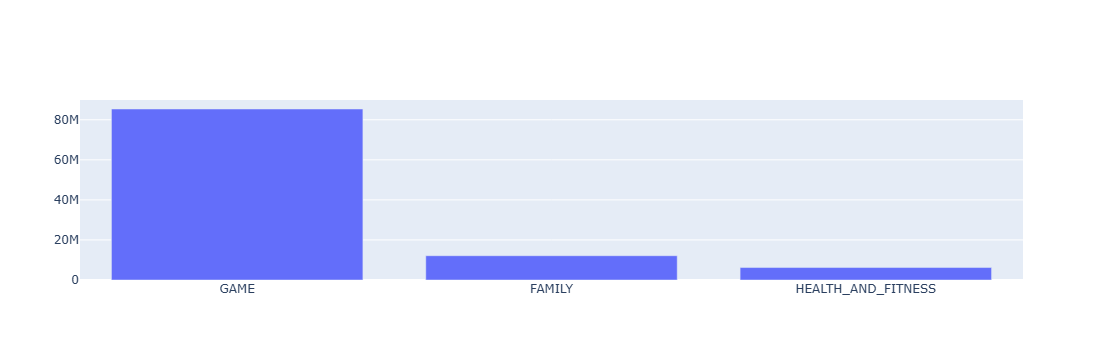

In [96]:
# FREE : AVERAGE INSTALLS

fig6.add_trace(
    go.Bar(
        x=free_df["Category"],
        y=free_df["Average_Installs"],
        name="Free - Avg Installs",
        offsetgroup="Free",

        hovertemplate=
        "<b>Category:</b> %{x}<br>" +
        "<b>Type:</b> Free<br>" +
        "<b>Average Installs:</b> %{y:,.0f}<extra></extra>"
    )
)

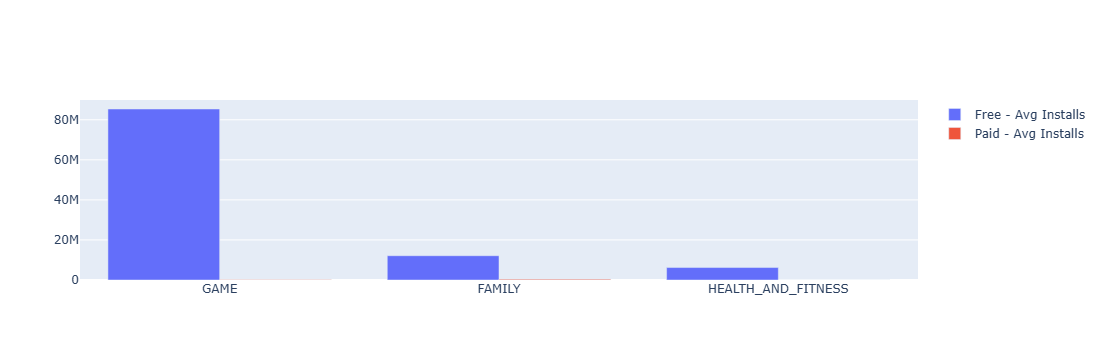

In [97]:
# PAID : AVERAGE INSTALLS

fig6.add_trace(
    go.Bar(
        x=paid_df["Category"],
        y=paid_df["Average_Installs"],
        name="Paid - Avg Installs",
        offsetgroup="Paid",

        hovertemplate=
        "<b>Category:</b> %{x}<br>" +
        "<b>Type:</b> Paid<br>" +
        "<b>Average Installs:</b> %{y:,.0f}<extra></extra>"
    )
)

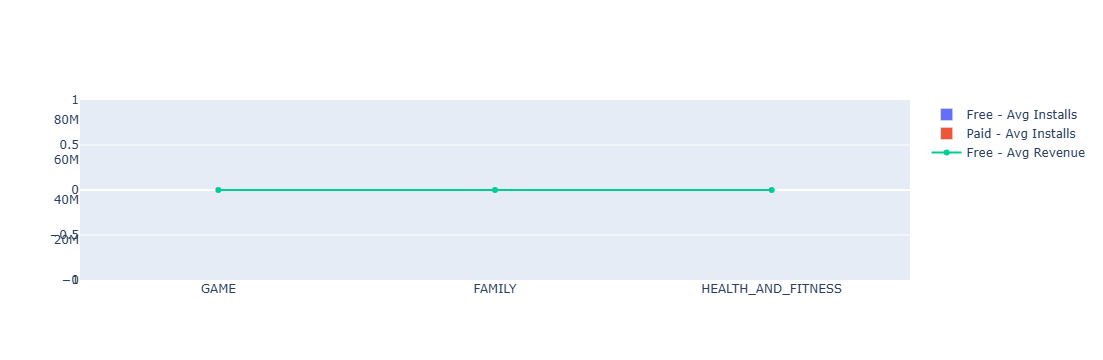

In [98]:
# FREE : AVERAGE REVENUE

fig6.add_trace(
    go.Scatter(
        x=free_df["Category"],
        y=free_df["Average_Revenue"],
        name="Free - Avg Revenue",
        mode="lines+markers",
        yaxis="y2",

        hovertemplate=
        "<b>Category:</b> %{x}<br>" +
        "<b>Type:</b> Free<br>" +
        "<b>Average Revenue:</b> $%{y:,.2f}<extra></extra>"
    )
)


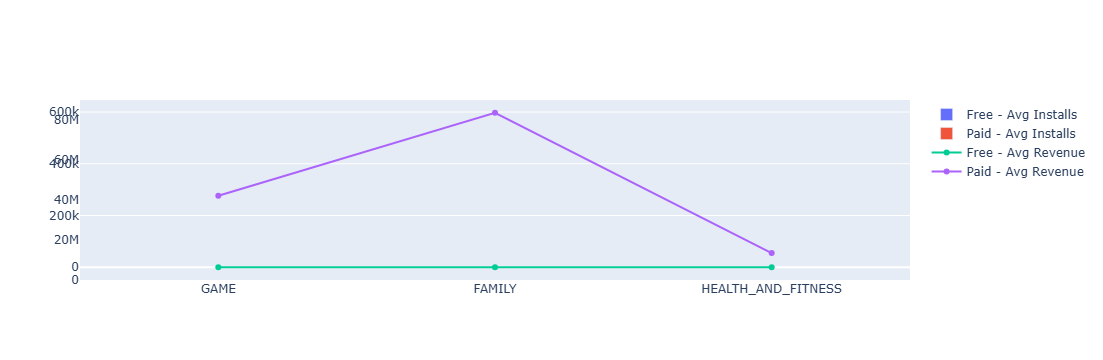

In [99]:
# PAID : AVERAGE REVENUE

fig6.add_trace(
    go.Scatter(
        x=paid_df["Category"],
        y=paid_df["Average_Revenue"],
        name="Paid - Avg Revenue",
        mode="lines+markers",
        yaxis="y2",

        hovertemplate=
        "<b>Category:</b> %{x}<br>" +
        "<b>Type:</b> Paid<br>" +
        "<b>Average Revenue:</b> $%{y:,.2f}<extra></extra>"
    )
)

In [101]:
# FINAL CHART LAYOUT

fig6.update_layout(

    title=dict(
        text="Task 6 : Average Installs vs Average Revenue - Free vs Paid",
        x=0.5,
        xanchor="center"
    ),

    # X AXIS

    xaxis=dict(
        title="Top 3 App Categories",

        categoryorder="array",

        categoryarray=top_3_categories,

        tickangle=0,

        automargin=True
    ),

    # LEFT Y AXIS : AVERAGE INSTALLS

    yaxis=dict(
        title="Average Installs",

        showgrid=True,

        gridcolor="lightgray",

        automargin=True
    ),

    # RIGHT Y AXIS : AVERAGE REVENUE

    yaxis2=dict(
        title="Average Revenue ($)",

        overlaying="y",

        side="right",

        showgrid=False,

        automargin=True
    ),

    # BAR MODE

    barmode="group",

    # TEMPLATE

    template="plotly_white",

    # SIZE

    width=1200,

    height=700,

    # HOVER

    hovermode="x unified",

    # LEGEND

    legend=dict(
        title="Metrics",

        orientation="h",

        x=0.5,

        xanchor="center",

        y=1.10
    ),

    # MARGINS

    margin=dict(
        t=140,
        r=180,
        l=120,
        b=120
    )
)


# GRID

fig6.update_xaxes(
    showgrid=True,
    gridcolor="lightgray"
)

fig6.update_yaxes(
    showgrid=True,
    gridcolor="lightgray"
)


# PREVENT AUTOMATIC DUPLICATE DISPLAY

fig6.update_layout()

# ============================================================
# TASK 6 : TIME RESTRICTION
# ONLY 1 PM TO 2 PM IST
# ============================================================

DEBUG_MODE = False

if DEBUG_MODE or is_time_between(13, 14):

    fig6.show()

else:

    print("""
============================================================
TASK 6 : CHART HIDDEN
============================================================

This chart is available only between
1 PM IST and 2 PM IST.

Current time is outside the allowed time window.
============================================================
""")


TASK 6 : CHART HIDDEN

This chart is available only between
1 PM IST and 2 PM IST.

Current time is outside the allowed time window.



In [102]:
# TASK 6 : APPLY TOP 3 CATEGORY FILTER

task6_df = task6_df[
    task6_df["Category"].isin(top_3_categories)
].copy()

print("=" * 60)
print("TASK 6 : TOP 3 CATEGORY FILTER APPLIED")
print("=" * 60)

print("Categories :", task6_df["Category"].unique())
print("Category Count :", task6_df["Category"].nunique())
print("Rows :", len(task6_df))

print(
    "Only Top 3 Categories :",
    set(task6_df["Category"]).issubset(set(top_3_categories))
)

TASK 6 : TOP 3 CATEGORY FILTER APPLIED
Categories : ['HEALTH_AND_FITNESS' 'GAME' 'FAMILY']
Category Count : 3
Rows : 1958
Only Top 3 Categories : True


Revenue Requirement Verification

In [103]:
# TASK 6 : REVENUE FILTER VERIFICATION

print("=" * 60)
print("TASK 6 : REVENUE FILTER VERIFICATION")
print("=" * 60)

# Free apps naturally have zero revenue
free_revenue_check = task6_df[
    task6_df["App_Type"] == "Free"
]["Revenue"].eq(0).all()

# Paid apps must satisfy Revenue >= $10,000
paid_revenue_check = task6_df[
    task6_df["App_Type"] == "Paid"
]["Revenue"].ge(10000).all()

print(
    "Free Apps Revenue = $0 :",
    free_revenue_check
)

print(
    "Paid Apps Revenue >= $10,000 :",
    paid_revenue_check
)

print(
    "Minimum Paid App Revenue :",
    task6_df.loc[
        task6_df["App_Type"] == "Paid",
        "Revenue"
    ].min()
)

print(
    "Maximum Paid App Revenue :",
    task6_df.loc[
        task6_df["App_Type"] == "Paid",
        "Revenue"
    ].max()
)

print("\n" + "=" * 60)

TASK 6 : REVENUE FILTER VERIFICATION
Free Apps Revenue = $0 : True
Paid Apps Revenue >= $10,000 : True
Minimum Paid App Revenue : 24900.000000000004
Maximum Paid App Revenue : 1990000.0



Final Verification

In [104]:
# TASK 6 : FINAL VERIFICATION

print("=" * 60)
print("TASK 6 : FINAL VERIFICATION")
print("=" * 60)

# 1. TOP 3 CATEGORIES

print("Top 3 Categories :", top_3_categories)
print("Top 3 Categories Count :", len(top_3_categories))


# 2. FILTER VERIFICATION

print("\nFILTER VERIFICATION")

print(
    "Installs >= 10,000 :",
    (task6_df["Installs"] >= 10000).all()
)

print(
    "Android Version > 4.0 :",
    (task6_df["Android Version"] > 4.0).all()
)

print(
    "Size > 15 MB :",
    (task6_df["Size_MB"] > 15).all()
)

print(
    "Content Rating = Everyone :",
    (task6_df["Content Rating"] == "Everyone").all()
)

print(
    "App Name <= 30 Characters :",
    (task6_df["App_Name_Length"] <= 30).all()
)


# 3. FREE vs PAID VERIFICATION

print("\nAPP TYPE VERIFICATION")

print(
    "Free Apps :",
    (task6_df["App_Type"] == "Free").sum()
)

print(
    "Paid Apps :",
    (task6_df["App_Type"] == "Paid").sum()
)


# 4. TOP 3 CATEGORY VERIFICATION

print("\nTOP 3 CATEGORY VERIFICATION")

print(
    "Only Top 3 Categories :",
    set(task6_df["Category"]).issubset(set(top_3_categories))
)

print(
    "Categories in Data :",
    task6_df["Category"].unique()
)


# 5. CHART DATA VERIFICATION

print("\nCHART DATA VERIFICATION")

print(
    "Chart Categories :",
    task6_chart_df["Category"].nunique()
)

print(
    "Chart App Types :",
    task6_chart_df["App_Type"].unique()
)

print(
    "Chart Traces :",
    len(fig6.data)
)


# 6. DUAL-AXIS VERIFICATION

print("\nDUAL-AXIS VERIFICATION")

print(
    "Revenue Axis Configured :",
    hasattr(fig6.layout, "yaxis2")
)


# 7. TIME RESTRICTION

print("\nTIME RESTRICTION")

print(
    "Allowed Time : 1 PM IST to 2 PM IST"
)

print(
    "Current IST Time :",
    datetime.now(
        pytz.timezone("Asia/Kolkata")
    ).strftime("%I:%M %p")
)


# FINAL STATUS

print("\n" + "=" * 60)
print("TASK 6 VERIFICATION COMPLETED")
print("=" * 60)

TASK 6 : FINAL VERIFICATION
Top 3 Categories : ['GAME', 'FAMILY', 'HEALTH_AND_FITNESS']
Top 3 Categories Count : 3

FILTER VERIFICATION
Installs >= 10,000 : True
Android Version > 4.0 : True
Size > 15 MB : True
Content Rating = Everyone : True
App Name <= 30 Characters : True

APP TYPE VERIFICATION
Free Apps : 1943
Paid Apps : 15

TOP 3 CATEGORY VERIFICATION
Only Top 3 Categories : True
Categories in Data : ['HEALTH_AND_FITNESS' 'GAME' 'FAMILY']

CHART DATA VERIFICATION
Chart Categories : 3
Chart App Types : ['Free' 'Paid']
Chart Traces : 4

DUAL-AXIS VERIFICATION
Revenue Axis Configured : True

TIME RESTRICTION
Allowed Time : 1 PM IST to 2 PM IST
Current IST Time : 05:17 PM

TASK 6 VERIFICATION COMPLETED


In [105]:
# ============================================================
# FINAL PROJECT AUDIT : TASK 1 TO TASK 6
# ============================================================

print("=" * 70)
print("FINAL PROJECT AUDIT : TASK 1 TO TASK 6")
print("=" * 70)


# ============================================================
# TASK 1
# ============================================================

print("\n" + "=" * 70)
print("TASK 1 VERIFICATION")
print("=" * 70)

try:

    print("Task 1 DataFrame Available :", "task1_df" in globals())

    if "task1_df" in globals():

        print(
            "Rows :",
            len(task1_df)
        )

        print(
            "Categories :",
            task1_df["Category_Display"].nunique()
        )

        print(
            "Rating > 3.5 :",
            (task1_df["Rating"] > 3.5).all()
        )

        print(
            "Reviews > 500 :",
            (task1_df["Reviews"] > 500).all()
        )

        print(
            "Installs > 50,000 :",
            (task1_df["Installs"] > 50000).all()
        )

        print(
            "Subjectivity > 0.5 :",
            (task1_df["Sentiment_Subjectivity"] > 0.5).all()
        )

    print(
        "Task 1 Chart Available :",
        "fig1" in globals()
    )

except Exception as e:

    print("Task 1 Verification Error :", e)


# ============================================================
# TASK 2
# ============================================================

print("\n" + "=" * 70)
print("TASK 2 VERIFICATION")
print("=" * 70)

try:

    print(
        "Task 2 DataFrame Available :",
        "task2_df" in globals()
    )

    if "task2_df" in globals():

        print(
            "Rows :",
            len(task2_df)
        )

        print(
            "Categories :",
            task2_df["Category"].nunique()
        )

    print(
        "Task 2 Chart Available :",
        "fig2" in globals()
    )

except Exception as e:

    print("Task 2 Verification Error :", e)


# ============================================================
# TASK 3
# ============================================================

print("\n" + "=" * 70)
print("TASK 3 VERIFICATION")
print("=" * 70)

try:

    print(
        "Task 3 DataFrame Available :",
        "task3_df" in globals()
    )

    if "task3_df" in globals():

        print(
            "Rows :",
            len(task3_df)
        )

        print(
            "Categories :",
            task3_df["Category_Display"].nunique()
        )

    print(
        "Task 3 Chart Available :",
        "fig3" in globals()
    )

except Exception as e:

    print("Task 3 Verification Error :", e)


# ============================================================
# TASK 4
# ============================================================

print("\n" + "=" * 70)
print("TASK 4 VERIFICATION")
print("=" * 70)

try:

    print(
        "Task 4 DataFrame Available :",
        "monthly4_df" in globals()
    )

    if "monthly4_df" in globals():

        print(
            "Rows :",
            len(monthly4_df)
        )

        print(
            "Categories :",
            monthly4_df["Category_Display"].nunique()
        )

        print(
            "Months :",
            monthly4_df["Month"].nunique()
        )

        print(
            "High Growth Months :",
            monthly4_df["High_Growth"].sum()
        )

    print(
        "Task 4 Chart Available :",
        "fig4" in globals()
    )

except Exception as e:

    print("Task 4 Verification Error :", e)


# ============================================================
# TASK 5
# ============================================================

print("\n" + "=" * 70)
print("TASK 5 VERIFICATION")
print("=" * 70)

try:

    print(
        "Task 5 DataFrame Available :",
        "task5_df" in globals()
    )

    if "task5_df" in globals():

        print(
            "Rows :",
            len(task5_df)
        )

        print(
            "Categories :",
            task5_df["Category"].nunique()
        )

        print(
            "Minimum Rating :",
            task5_df["Avg_Rating"].min()
        )

    print(
        "Task 5 Chart Available :",
        "fig5" in globals()
    )

    if "fig5" in globals():

        print(
            "Task 5 Chart Traces :",
            len(fig5.data)
        )

except Exception as e:

    print("Task 5 Verification Error :", e)


# ============================================================
# TASK 6
# ============================================================

print("\n" + "=" * 70)
print("TASK 6 VERIFICATION")
print("=" * 70)

try:

    print(
        "Task 6 DataFrame Available :",
        "task6_df" in globals()
    )

    if "task6_df" in globals():

        print(
            "Rows :",
            len(task6_df)
        )

        print(
            "Categories :",
            task6_df["Category"].nunique()
        )

        print(
            "Only Top 3 Categories :",
            set(task6_df["Category"]).issubset(
                set(top_3_categories)
            )
        )

        print(
            "Installs >= 10,000 :",
            (task6_df["Installs"] >= 10000).all()
        )

        print(
            "Android Version > 4.0 :",
            (task6_df["Android Version"] > 4.0).all()
        )

        print(
            "Size > 15 MB :",
            (task6_df["Size_MB"] > 15).all()
        )

        print(
            "Content Rating = Everyone :",
            (task6_df["Content Rating"] == "Everyone").all()
        )

        print(
            "App Name <= 30 Characters :",
            (task6_df["App_Name_Length"] <= 30).all()
        )

    print(
        "Task 6 Chart Available :",
        "fig6" in globals()
    )

    if "fig6" in globals():

        print(
            "Task 6 Chart Traces :",
            len(fig6.data)
        )

        print(
            "Dual Axis Available :",
            hasattr(fig6.layout, "yaxis2")
        )

except Exception as e:

    print("Task 6 Verification Error :", e)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT AUDIT COMPLETED")
print("=" * 70)

print("""
Task 1 : Audited
Task 2 : Audited
Task 3 : Audited
Task 4 : Audited
Task 5 : Audited
Task 6 : Audited

No charts were displayed by this audit cell.
""")

print("=" * 70)

FINAL PROJECT AUDIT : TASK 1 TO TASK 6

TASK 1 VERIFICATION
Task 1 DataFrame Available : True
Rows : 879
Task 1 Verification Error : 'Category_Display'

TASK 2 VERIFICATION
Task 2 DataFrame Available : True
Rows : 5
Categories : 5
Task 2 Chart Available : True

TASK 3 VERIFICATION
Task 3 DataFrame Available : True
Rows : 1525
Categories : 8
Task 3 Chart Available : True

TASK 4 VERIFICATION
Task 4 DataFrame Available : True
Rows : 37
Categories : 6
Months : 18
High Growth Months : 18
Task 4 Chart Available : True

TASK 5 VERIFICATION
Task 5 DataFrame Available : True
Rows : 10
Categories : 10
Minimum Rating : 4.007317073170732
Task 5 Chart Available : True
Task 5 Chart Traces : 2

TASK 6 VERIFICATION
Task 6 DataFrame Available : True
Rows : 1958
Categories : 3
Only Top 3 Categories : True
Installs >= 10,000 : True
Android Version > 4.0 : True
Size > 15 MB : True
Content Rating = Everyone : True
App Name <= 30 Characters : True
Task 6 Chart Available : True
Task 6 Chart Traces : 4
Dual 